<a href="https://colab.research.google.com/github/ipalaciosbm-byte/phishing-detection-roberta/blob/main/deteccion_phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

True
NVIDIA A100-SXM4-40GB
Fri Jun  6 08:36:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             46W /  400W |       5MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+--------------------

In [ ]:
from google.colab import drive

# Montamos Google Drive para guardar y cargar archivos
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets

In [ ]:
from google.colab import files

# Ruta al archivo CSV con los correos
uploaded = files.upload()

Saving CEAS_08.csv to CEAS_08.csv


In [ ]:
import pandas as pd

## PASO 1 : Cargamos el conjunto de dato para nuestro trabajo

# Se carga el archivo en dataframes para poder manejarlos
df = pd.read_csv("CEAS_08.csv")  # ajusta el nombre si el archivo es distinto
df.head() # Para comprobarar las primeras lineas del conjunto de datos

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
import re

## PASO 2: Procesamos el texto para de nuestro conjunto de datos y construimos los datos para ser procesados por el modelo

def limpiar_texto(subject, body):
    """
    Limpia y concatena el asunto y cuerpo de un correo electrónico.

    Parámetros:
    - subject (str): asunto del correo.
    - body (str): cuerpo del mensaje.

    Retorna:
    - str: texto concatenado y preprocesado.
    """
    # Convertimos los campos a string en caso de ser nulos y los concatenamos en una única cadena
    subject = str(subject) if pd.notnull(subject) else ""
    body = str(body) if pd.notnull(body) else ""
    text = f"Subject: {subject}. Body: {body}"

    # Eliminamos URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    # Eliminamos etiquetas HTML
    text = re.sub(r"<[^>]+>", "", text)

    # Normalizamos espacios
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Aplicamos la función a cada fila del DataFrame
df['text'] = df.apply(lambda row: limpiar_texto(row['subject'], row['body']), axis=1)

df[['text', 'label']].head() # comprobamos como ha quedado el procesado del texto mediante una prueba

IndentationError: unexpected indent (<ipython-input-1-1642523376>, line 5)

In [ ]:
from transformers import RobertaTokenizer
import torch

## PASO 3: Vamos a realizar una tokenización #####
#convertimos las palabras en números para que el modelo lo pueda entender
#input_ids: secuencia de números que representan cada token del texto.

#attention_mask: indica qué posiciones son tokens reales (1) y cuáles son relleno o padding (0)

# Cargamos el tokenizer de roberta-base (puede tardar unos segundos la 1ª vez)
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
# Función para tokenizar cada fila
def tokenizar(texto):
    return tokenizer(
        texto,
        padding='max_length',     # rellenamos con ceros si es más corto
        truncation=True,          # cortamos si se pasa del máximo
        max_length=512,           # longitud máxima de RoBERTa
        return_tensors='pt'       # formato PyTorch
    )
# Ejemplo con una fila
ejemplo = df['text'].iloc[0]
tokens = tokenizar(ejemplo)
print(type(tokenizer))
# Visualizamos
print("Texto original:\n", ejemplo)
print("\nTokens:\n", tokens['input_ids'][0])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

<class 'transformers.models.roberta.tokenization_roberta.RobertaTokenizer'>
Texto original:
 Subject: Never agree to be a loser. Body: Buck up, your troubles caused by small dimension will soon be over! Become a lover no woman will be able to resist! come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.

Tokens:
 tensor([    0, 47159,    35,  9154,  2854,     7,    28,    10, 22650,     4,
        13048,    35, 11771,    62,     6,   110, 13656,  1726,    30,   650,
        21026,    40,  1010,    28,    81,   328, 26861,    10, 16095,   117,
          693,    40,    28,   441,     7, 11942,   328,   283,     4,  1648,
           25, 12281, 12039,    58,  6346,   159,     5,  2827,     6,     5,
         3366,   268, 39142,   366, 35885,    50,    10,  5226,     4,    91,
           21,   202,    45,   686,     4,   100,   109,     5,   276,     4,
            2,     1,     1,     1,     1,     1,     1,   

In [ ]:
from transformers import RobertaTokenizer
import torch

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

input_ids = []
attention_masks = []

for texto in df['text']:
    codificado = tokenizer(
        texto,
        padding='max_length',
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    input_ids.append(codificado['input_ids'][0])
    attention_masks.append(codificado['attention_mask'][0])


labels = torch.tensor(df['label'].values)
input_ids = torch.stack(input_ids)
attention_masks = torch.stack(attention_masks)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# División 80% - 20%
train_inputs, val_inputs, train_labels, val_labels = train_test_split(
    input_ids, labels, test_size=0.2, random_state=42
)

train_masks, val_masks = train_test_split(
    attention_masks, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset = TensorDataset(val_inputs, val_masks, val_labels)

batch_size = 16

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

val_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

In [ ]:
from transformers import RobertaForSequenceClassification, get_scheduler
from torch.optim import AdamW
import torch.nn as nn
import os
import pickle
import time

# Dispositivo (ya estará en GPU si lo hiciste bien)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ruta_guardado = "/content/drive/MyDrive/TFG_roberta_v2"
os.makedirs(ruta_guardado, exist_ok=True)

with open('/content/drive/MyDrive/TFG_roberta_v2/val_dataloader.pkl', 'wb') as f:
    pickle.dump(val_dataloader, f)

# Cargar modelo RoBERTa para clasificación binaria
modelo = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
modelo.to(device)

# Configurar optimizador y scheduler
optimizer = AdamW(modelo.parameters(), lr=2e-5, eps=1e-8)
epochs = 3
total_steps = len(train_dataloader) * epochs
all_losses = []

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Función de pérdida
loss_fn = nn.CrossEntropyLoss()

# Entrenamiento
for epoch in range(epochs):
    print(f"\n🚀 Época {epoch + 1} de {epochs}")
    print("-" * 30)

    t0 = time.time()
    modelo.train()
    total_loss = 0

    for step, batch in enumerate(train_dataloader):
        b_input_ids, b_input_mask, b_labels = [tensor.to(device) for tensor in batch]

        modelo.zero_grad()

        salida = modelo(
            input_ids=b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = salida.loss
        total_loss += loss.item()
        all_losses.append(loss.item())

        loss.backward()
        optimizer.step()
        scheduler.step()

        if step % 100 == 0 and step != 0:
            print(f"Paso {step}, Pérdida: {loss.item():.4f}")

    avg_train_loss = total_loss / len(train_dataloader)
    duracion = time.time() - t0
    print(f"\n📉 Pérdida media: {avg_train_loss:.4f}")
    print(f"⏱️ Tiempo de época: {duracion:.2f} segundos")
    print("✅ Entrenamiento finalizado con éxito.")
      # GUARDAR MODELO Y PÉRDIDAS
    epoca_dir = f"{ruta_guardado}/epoca_{epoch+1}"
    modelo.save_pretrained(epoca_dir)
    tokenizer.save_pretrained(epoca_dir)
    with open(f"{epoca_dir}/losses.pkl", "wb") as f:
        pickle.dump(all_losses, f)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Época 1 de 3
------------------------------
Paso 100, Pérdida: 0.0183
Paso 200, Pérdida: 0.1960
Paso 300, Pérdida: 0.0033
Paso 400, Pérdida: 0.0037
Paso 500, Pérdida: 0.0051
Paso 600, Pérdida: 0.0798
Paso 700, Pérdida: 0.0101
Paso 800, Pérdida: 0.0033
Paso 900, Pérdida: 0.6294
Paso 1000, Pérdida: 0.0013
Paso 1100, Pérdida: 0.0553
Paso 1200, Pérdida: 0.0005
Paso 1300, Pérdida: 0.0077
Paso 1400, Pérdida: 0.0002
Paso 1500, Pérdida: 0.0008
Paso 1600, Pérdida: 0.0012
Paso 1700, Pérdida: 0.0002
Paso 1800, Pérdida: 0.0008
Paso 1900, Pérdida: 0.0005

📉 Pérdida media: 0.0288
⏱️ Tiempo de época: 593.72 segundos
✅ Entrenamiento finalizado con éxito.

🚀 Época 2 de 3
------------------------------
Paso 100, Pérdida: 0.0002
Paso 200, Pérdida: 0.1142
Paso 300, Pérdida: 0.0003
Paso 400, Pérdida: 0.0031
Paso 500, Pérdida: 0.0743
Paso 600, Pérdida: 0.0005
Paso 700, Pérdida: 0.0001
Paso 800, Pérdida: 0.0077
Paso 900, Pérdida: 0.0002
Paso 1000, Pérdida: 0.0058
Paso 1100, Pérdida: 0.0001
Paso 1200, Pérd

In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from safetensors.torch import load_file
import torch
import os
import pickle

# Ruta al modelo guardado
ruta_modelo = "/content/drive/MyDrive/TFG_roberta_v2/epoca_3"

# Cargar tokenizer
tokenizer = RobertaTokenizer.from_pretrained(ruta_modelo, local_files_only=True)

# Cargar modelo
modelo = RobertaForSequenceClassification.from_pretrained(ruta_modelo, local_files_only=True)

# Cargar pesos desde model.safetensors
modelo_pesos = os.path.join(ruta_modelo, "model.safetensors")
state_dict = load_file(modelo_pesos)
modelo.load_state_dict(state_dict)

# Mover modelo al dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)
modelo.eval()

# Cargar lista de pérdidas
with open(f"{ruta_modelo}/losses.pkl", "rb") as f:
    all_losses = pickle.load(f)

# Cargar dataloader de validación
with open(f"/content/drive/MyDrive/TFG_roberta_v2/val_dataloader.pkl", "rb") as f:
    val_dataloader = pickle.load(f)

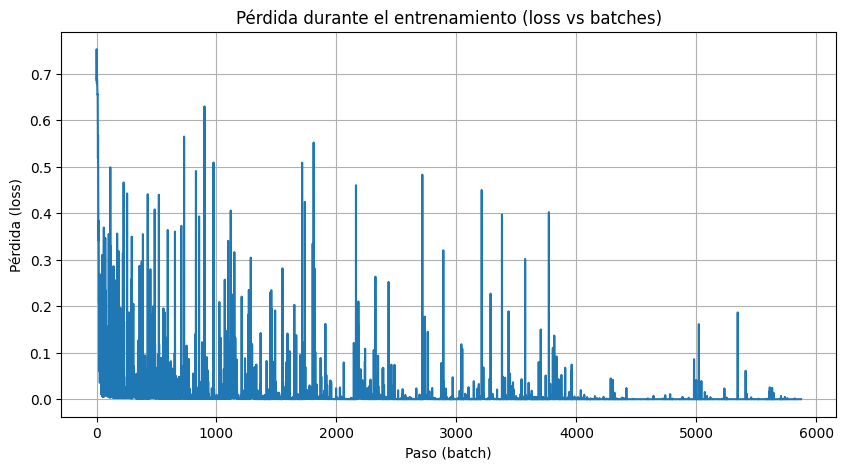

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(all_losses)
plt.xlabel("Paso (batch)")
plt.ylabel("Pérdida (loss)")
plt.title("Pérdida durante el entrenamiento (loss vs batches)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import numpy as np



modelo.eval()  # Modo evaluación
predicciones = []
etiquetas_reales = []

with torch.no_grad():
    for batch in val_dataloader:
        b_input_ids, b_input_mask, b_labels = [tensor.to(device) for tensor in batch]

        outputs = modelo(
            input_ids=b_input_ids,
            attention_mask=b_input_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predicciones.extend(preds.cpu().numpy())
        etiquetas_reales.extend(b_labels.cpu().numpy())

# Convertimos a arrays
predicciones = np.array(predicciones)
etiquetas_reales = np.array(etiquetas_reales)

# Métricas
accuracy = accuracy_score(etiquetas_reales, predicciones) 	# % de aciertos totales
precision = precision_score(etiquetas_reales, predicciones) # % de verdaderos positivos entre los que predije como phishing
recall = recall_score(etiquetas_reales, predicciones)       # % de phishing detectados entre todos los phishing reales
f1 = f1_score(etiquetas_reales, predicciones)               # Promedio balanceado entre precision y recall
mcc = matthews_corrcoef(etiquetas_reales, predicciones)     # explicado en el libro

print(f"MCC: {mcc:.4f}")
print(f"🎯 Accuracy:  {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"📥 Recall:    {recall:.4f}")
print(f"📊 F1-score:  {f1:.4f}")

MCC: 0.9964
🎯 Accuracy:  0.9982
✅ Precision: 0.9982
📥 Recall:    0.9986
📊 F1-score:  0.9984


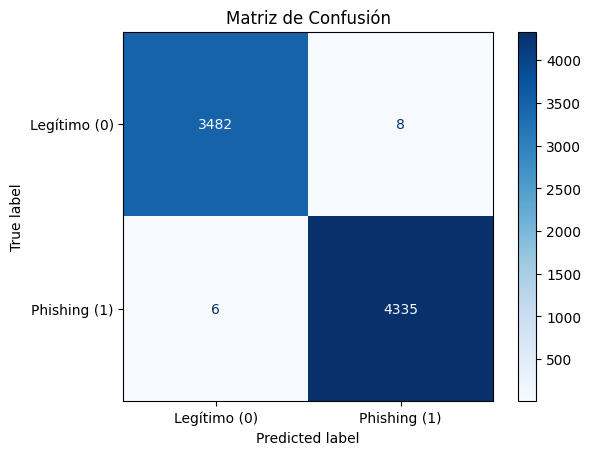

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcular matriz
cm = confusion_matrix(etiquetas_reales, predicciones)

# Mostrar con etiquetas
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legítimo (0)", "Phishing (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.grid(False)
plt.show()

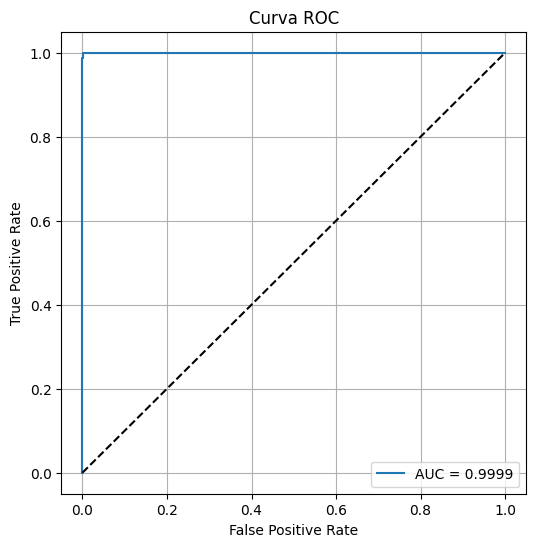

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtener probabilidades para clase 1 (phishing)
modelo.eval()
probs = []

with torch.no_grad():
    for batch in val_dataloader:
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
        outputs = modelo(input_ids=b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits
        prob = torch.softmax(logits, dim=1)[:, 1]  # Probabilidad clase 1
        probs.extend(prob.cpu().numpy())

# Curva ROC
fpr, tpr, _ = roc_curve(etiquetas_reales, probs)
auc = roc_auc_score(etiquetas_reales, probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')  # línea diagonal (aleatorio)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

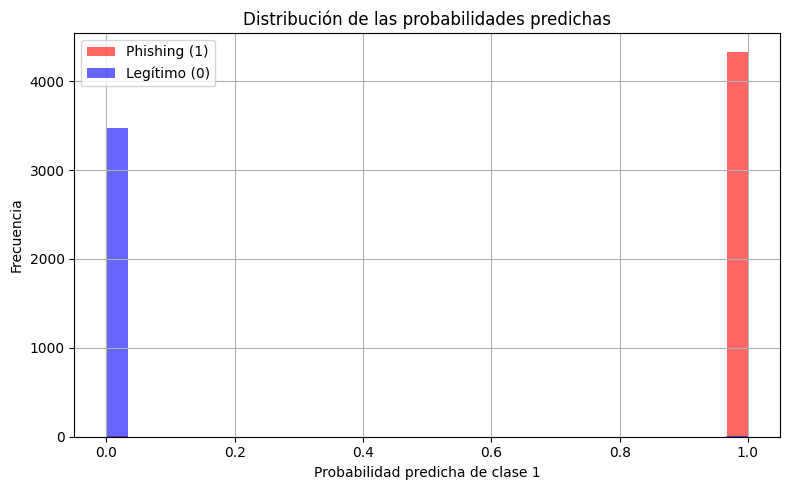

In [ ]:
import matplotlib.pyplot as plt
labels = etiquetas_reales
# Convertimos a listas si no lo son
probs_list = probs.tolist() if not isinstance(probs, list) else probs
labels_list = labels.tolist() if not isinstance(labels, list) else labels

# Convertimos a array por eficiencia
import numpy as np
probs_array = np.array(probs_list)
labels_array = np.array(labels_list)

# Dividir las probabilidades según la clase real
phishing_probs = probs_array[labels_array == 1]
legit_probs = probs_array[labels_array == 0]

# Dibujar histograma sin KDE, con menos bins
plt.figure(figsize=(8, 5))
plt.hist(phishing_probs, bins=30, alpha=0.6, color='red', label='Phishing (1)')
plt.hist(legit_probs, bins=30, alpha=0.6, color='blue', label='Legítimo (0)')
plt.xlabel('Probabilidad predicha de clase 1')
plt.ylabel('Frecuencia')
plt.title('Distribución de las probabilidades predichas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# FUNCION DE CLASIFICACIÓN DE EMAIL

def clasificar_email(texto):
    modelo.eval()
    inputs = tokenizer(texto, return_tensors="pt", padding='max_length', truncation=True, max_length=512).to(device)
    with torch.no_grad():
        salida = modelo(**inputs)
        probs = torch.nn.functional.softmax(salida.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    return pred, probs.cpu().numpy()

# EJEMPLO:
email1 = """Subject: Important: Your account has been suspended

Dear user,

We have detected suspicious activity in your bank account. Please verify your identity immediately to avoid permanent suspension.

Click here to confirm your information: http://secure-bank-verify.com

Sincerely,
Bank Security Team"""
pred1, score1 = clasificar_email(email1)
print("Etiqueta predicha email 1:", pred1, "\nProbabilidades:", score1)
email2 = """Subject: Meeting agenda for Monday

Hi team,

Please find attached the agenda for our next weekly meeting. Let me know if you’d like to add anything.

Best regards,
Ana"""
pred2, score2 = clasificar_email(email2)
print("Etiqueta predicha email 2:", pred2, "\nProbabilidades:", score2)
email3 = """Subject: Final reminder - Reward awaiting

Congratulations! You have been selected for an exclusive reward from our partners. Act now to claim your gift before the deadline.

Claim here: http://exclusive-gifts-offer.com

Thank you for participating."""
pred3, score3 = clasificar_email(email3)
print("Etiqueta predicha email 3:", pred3, "\nProbabilidades:", score3)

Etiqueta predicha email 1: 1 
Probabilidades: [[0.00369119 0.99630874]]
Etiqueta predicha email 2: 0 
Probabilidades: [[9.9994004e-01 5.9931746e-05]]
Etiqueta predicha email 3: 1 
Probabilidades: [[3.3897832e-05 9.9996614e-01]]
